In [ ]:
import numpy as np
import pandas as pd


# Project Objective:
The objective of this project is to develop a machine learning model capable of predicting the selling price of used cars based on various vehicle attributes such as manufacturer, model, year, fuel type, transmission, odometer reading, condition, and other related features.
This project aims to analyze the factors affecting car prices through exploratory data analysis (EDA), data preprocessing, feature engineering, and regression techniques. Different machine learning algorithms such as Linear Regression, Decision Tree Regressor, Random Forest Regressor, and XGBoost Regressor will be implemented and compared to identify the most accurate model.
The final goal is to build an efficient predictive system that can help buyers, sellers, and businesses estimate fair used car prices and support better decision-making in the automobile market.

* Dataset Source - **Kaggle**

In [ ]:
df=pd.read_csv('vehicles.csv',on_bad_lines='skip',encoding='latin1',engine='python')

In [ ]:
df.shape

(426880, 26)

In [ ]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [ ]:
df.dtypes

,0
id,int64
url,object
region,object
region_url,object
price,int64
year,float64
manufacturer,object
model,object
condition,object
cylinders,object


The features were selected based on their relevance to car pricing. Important attributes such as year, manufacturer, model, fuel type, condition, odometer, transmission, and state were retained as they significantly affect the resale value of a vehicle. Irrelevant and noisy columns were removed to improve model efficiency and prediction performance.

In [ ]:
data=df[[
    'year',
    'manufacturer',
    'model',
    'condition',
    'cylinders',
    'fuel',
    'odometer',
    'title_status',
    'transmission',
    'drive',
    'size',
    'type',
    'paint_color',
    'state','price'
]]

In [ ]:
data=data.copy()
data

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,price
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,6000
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,11900
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,21000
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,1500
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,4900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,NaN,sedan,NaN,wy,23590
426876,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,fwd,NaN,sedan,red,wy,30590
426877,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,NaN,hatchback,white,wy,34990
426878,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,NaN,sedan,silver,wy,28990


In [ ]:
data.isna().sum()

,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678
fuel,3013
odometer,4400
title_status,8242
transmission,2556
drive,130567


In [ ]:
## WE WILL PRUNE MISSING VALUES WITH LESS PERCENTAGE

In [ ]:
data.dropna(subset=['year','manufacturer','model','transmission','title_status','fuel','odometer'],inplace=True)

In [ ]:
data.isna().sum()

,0
year,0
manufacturer,0
model,0
condition,157282
cylinders,161353
fuel,0
odometer,0
title_status,0
transmission,0
drive,115076


In [ ]:
## Size has large no. of null values lets remove this column
data.drop(columns='size',inplace=True)

In [ ]:
cat_cols = ['condition', 'cylinders', 'drive', 'type', 'paint_color']

for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

/tmp/ipykernel_84770/2697794127.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [ ]:
## Filling Categories with mode

In [ ]:
data.isna().sum()

,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0
transmission,0
drive,0


In [ ]:
## Checking duplicates and droping them

In [ ]:
data.duplicated().sum()

np.int64(116755)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,price
27,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,4wd,pickup,white,al,33590
28,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,4wd,pickup,blue,al,22590
29,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,4wd,pickup,red,al,39590
30,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,4wd,pickup,red,al,30990
31,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,15000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,sedan,white,wy,23590
426876,2020.0,volvo,s60 t5 momentum sedan 4d,good,6 cylinders,gas,12029.0,clean,other,fwd,sedan,red,wy,30590
426877,2020.0,cadillac,xt4 sport suv 4d,good,6 cylinders,diesel,4174.0,clean,other,4wd,hatchback,white,wy,34990
426878,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,sedan,silver,wy,28990


In [ ]:
data.reset_index(drop=True,inplace=True)

In [ ]:
data

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,price
0,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,4wd,pickup,white,al,33590
1,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,4wd,pickup,blue,al,22590
2,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,4wd,pickup,red,al,39590
3,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,4wd,pickup,red,al,30990
4,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,15000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272844,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,fwd,sedan,white,wy,23590
272845,2020.0,volvo,s60 t5 momentum sedan 4d,good,6 cylinders,gas,12029.0,clean,other,fwd,sedan,red,wy,30590
272846,2020.0,cadillac,xt4 sport suv 4d,good,6 cylinders,diesel,4174.0,clean,other,4wd,hatchback,white,wy,34990
272847,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,fwd,sedan,silver,wy,28990


In [ ]:
data.describe()

,year,odometer,price
count,272849.000000,2.728490e+05,2.728490e+05
mean,2010.748245,1.013200e+05,8.280628e+04
std,9.475115,2.044064e+05,1.368054e+07
min,1900.000000,0.000000e+00,0.000000e+00
25%,2008.000000,4.132500e+04,5.650000e+03
50%,2013.000000,9.094200e+04,1.269000e+04
75%,2017.000000,1.385560e+05,2.459000e+04
max,2022.000000,1.000000e+07,3.736929e+09


In [ ]:
data.describe(include='object')

,manufacturer,model,condition,cylinders,fuel,title_status,transmission,drive,type,paint_color,state
count,272849,272849,272849,272849,272849,272849,272849,272849,272849,272849,272849
unique,41,21866,6,8,5,6,3,3,13,12,51
top,ford,f-150,good,6 cylinders,gas,clean,automatic,4wd,sedan,white,ca
freq,46709,5015,182093,167882,234629,262097,221877,162503,118829,126084,28988


In [ ]:
data.manufacturer.unique()

array(['gmc', 'chevrolet', 'toyota', 'ford', 'jeep', 'nissan', 'ram',
       'mazda', 'cadillac', 'honda', 'dodge', 'lexus', 'jaguar', 'buick',
       'chrysler', 'volvo', 'audi', 'infiniti', 'lincoln', 'alfa-romeo',
       'subaru', 'acura', 'hyundai', 'mercedes-benz', 'bmw', 'mitsubishi',
       'volkswagen', 'porsche', 'kia', 'ferrari', 'mini', 'pontiac',
       'fiat', 'rover', 'tesla', 'saturn', 'mercury', 'harley-davidson',
       'datsun', 'aston-martin', 'land rover'], dtype=object)

In [ ]:
data.manufacturer.value_counts()

,count
manufacturer,
ford,46709
chevrolet,36182
toyota,23351
honda,15530
nissan,13086
jeep,12677
gmc,10587
ram,10341
bmw,9484


In [ ]:
data.model.unique()

array(['sierra 1500 crew cab slt', 'silverado 1500',
       'silverado 1500 crew', ..., 'cj 3a willys', 'rx& gls sport',
       'gand wagoneer'], dtype=object)

In [ ]:
data['model']=data['model'].str.lower()
data['model']=data['model'].str.replace(r'[^a-zA-Z0-9 ]','',regex=True)
data['model']=data['model'].str.strip()
data['model']=data['model'].str.replace(r'\s+',' ',regex=True)

In [ ]:
data.model.value_counts()

,count
model,
f150,5826
silverado 1500,3285
1500,2677
camry,2306
accord,2249
...,...
ex37,1
brothers touring sedan,1
resto mod,1


In [ ]:
data.loc[(data['manufacturer']=='chevrolet') & (data['model']=='1500'),'model']='silverado 1500'

The high-cardinality model feature was simplified by grouping less frequent car models into an "other" category. This helps reduce noise, lowers dimensionality, and improves model efficiency while retaining important information from commonly occurring models.

In [ ]:
top_models=data['model'].value_counts().head(3000).index
data['model']=data['model'].apply(lambda x: x if x in top_models else 'other')


In [ ]:
data['model'].value_counts()

,count
model,
other,38638
f150,5826
silverado 1500,3351
1500,2611
camry,2306
...,...
x3 xdrive 28i,10
corolla hatchback se 4d,10
romeo giulia ti sport sedan,10


In [ ]:
data=data[data['model']!='1500']

In [ ]:
data.condition.unique()

array(['good', 'excellent', 'fair', 'like new', 'new', 'salvage'],
      dtype=object)

In [ ]:
data.condition.value_counts()

,count
condition,
good,180314
excellent,66946
like new,15862
fair,5680
new,928
salvage,508


In [ ]:
data.cylinders.unique()

array(['8 cylinders', '6 cylinders', '4 cylinders', '5 cylinders',
       '10 cylinders', '3 cylinders', 'other', '12 cylinders'],
      dtype=object)

In [ ]:
data.cylinders.value_counts()

,count
cylinders,
6 cylinders,166570
4 cylinders,54725
8 cylinders,45669
5 cylinders,1257
10 cylinders,908
other,628
3 cylinders,388
12 cylinders,93


In [ ]:
data.fuel.unique()

array(['gas', 'other', 'diesel', 'hybrid', 'electric'], dtype=object)

In [ ]:
data.fuel.value_counts()

,count
fuel,
gas,232221
other,17404
diesel,15964
hybrid,3593
electric,1056


In [ ]:
data.title_status.unique()

array(['clean', 'rebuilt', 'lien', 'salvage', 'missing', 'parts only'],
      dtype=object)

In [ ]:
data.title_status.value_counts()

,count
title_status,
clean,259594
rebuilt,5648
salvage,3076
lien,1264
missing,523
parts only,133


In [ ]:
data.transmission.unique()

array(['other', 'automatic', 'manual'], dtype=object)

In [ ]:
data.transmission.value_counts()

,count
transmission,
automatic,219363
other,33872
manual,17003


In [ ]:
data.drive.value_counts()

,count
drive,
4wd,160392
fwd,72274
rwd,37572


In [ ]:
data.drive.unique()

array(['4wd', 'rwd', 'fwd'], dtype=object)

In [ ]:
data.type.unique()

array(['pickup', 'truck', 'other', 'sedan', 'coupe', 'SUV', 'hatchback',
       'mini-van', 'offroad', 'van', 'convertible', 'wagon', 'bus'],
      dtype=object)

In [ ]:
data.type.value_counts()

,count
type,
sedan,118232
SUV,51530
pickup,23154
truck,20939
other,12064
coupe,11915
hatchback,10673
wagon,6872
van,5281


In [ ]:
data.paint_color.unique()

array(['white', 'blue', 'red', 'black', 'silver', 'grey', 'brown',
       'yellow', 'orange', 'green', 'custom', 'purple'], dtype=object)

In [ ]:
data.paint_color.value_counts()

,count
paint_color,
white,124790
black,41092
silver,29085
blue,20954
red,19579
grey,17434
green,5101
custom,4662
brown,4557


In [ ]:
data.state.value_counts()

,count
state,
ca,28798
fl,16508
tx,15256
ny,12511
or,10380
oh,10327
pa,8678
mi,8637
wa,8334


In [ ]:
data.state.unique()

array(['al', 'ak', 'az', 'ar', 'ca', 'co', 'ct', 'dc', 'de', 'fl', 'ga',
       'hi', 'id', 'il', 'in', 'ia', 'ks', 'ky', 'la', 'me', 'md', 'ma',
       'mi', 'mn', 'ms', 'mo', 'mt', 'nc', 'ne', 'nv', 'nj', 'nm', 'ny',
       'nh', 'nd', 'oh', 'ok', 'or', 'pa', 'ri', 'sc', 'sd', 'tn', 'tx',
       'ut', 'vt', 'va', 'wa', 'wv', 'wi', 'wy'], dtype=object)

# Visualization & Outlier Handling

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
data.shape

(270238, 14)

* as dataset has huge datapoint we will take random sample , according to statistics random sample follows same pattern as that of population

In [ ]:
df=data.sample(n=20000,random_state=42)

In [ ]:
df.reset_index(drop=True,inplace=True)

In [ ]:
df.to_csv('Sampledf.csv',index=False)

In [ ]:
df=pd.read_csv('Sampledf.csv')

In [ ]:
df.head()

,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,price
0,2010.0,toyota,corolla s,like new,4 cylinders,gas,152000.0,clean,automatic,4wd,sedan,silver,fl,7900
1,2013.0,hyundai,sonata,excellent,4 cylinders,gas,153622.0,clean,automatic,fwd,sedan,white,il,6850
2,2010.0,ford,taurus,good,6 cylinders,gas,135170.0,clean,automatic,4wd,sedan,white,mi,5995
3,2012.0,gmc,acadia,like new,6 cylinders,gas,60000.0,clean,automatic,4wd,SUV,blue,ca,15000
4,2015.0,chrysler,200,excellent,4 cylinders,gas,132000.0,clean,automatic,4wd,sedan,white,mi,11999


In [ ]:
df.shape

(20000, 14)

## UNIVARIATE CONTINOUS

## PRICE

In [ ]:
## EXTREME OUTLIERS AND UNREALISTIC VALUES REMOVAL
df=df[(df['price']<100000)&(df['price']>500)]
df=df[(df['year']<2025)&(df['year']>1990)]
df=df[df['odometer']<500000]


In [ ]:
df.shape

(17602, 14)

In [ ]:
df.describe()

,year,odometer,price
count,17602.000000,17602.000000,17602.000000
mean,2011.780309,98343.682479,17877.137598
std,5.959846,64297.991554,14011.372918
min,1991.000000,0.000000,507.000000
25%,2008.000000,42668.250000,6995.000000
50%,2013.000000,94895.500000,13995.000000
75%,2017.000000,142000.000000,25990.000000
max,2021.000000,432777.000000,99700.000000


In [ ]:
df.describe(include='object')

,manufacturer,model,condition,cylinders,fuel,title_status,transmission,drive,type,paint_color,state
count,17602,17602,17602,17602,17602,17602,17602,17602,17602,17602,17602
unique,39,2407,6,8,5,6,3,3,13,12,51
top,ford,other,good,6 cylinders,gas,clean,automatic,4wd,sedan,white,ca
freq,3008,2346,11678,10837,15090,16863,14228,10432,7738,7970,1808


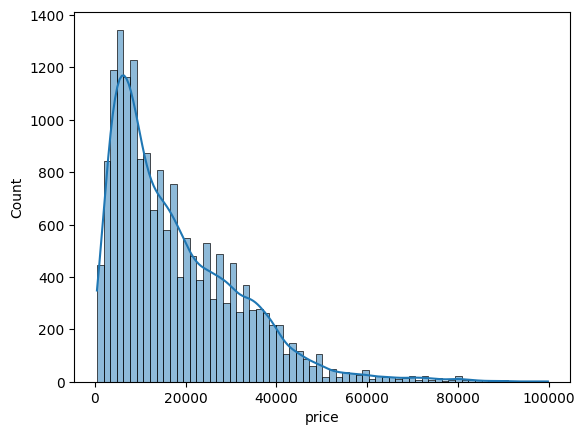

In [ ]:
sns.histplot(data=df,x='price',kde=True)
plt.show()

## year

<Axes: xlabel='year'>

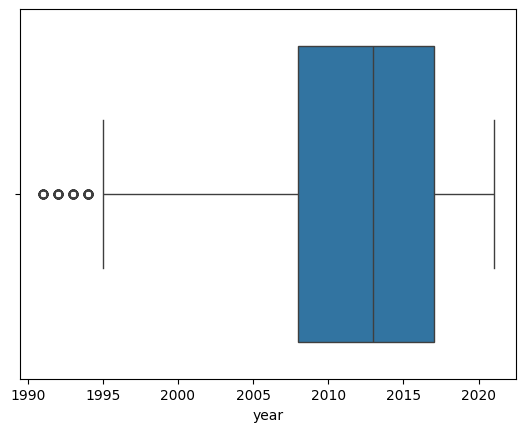

In [ ]:
sns.boxplot(data=df,x='year')

# Odometer

<Axes: xlabel='odometer'>

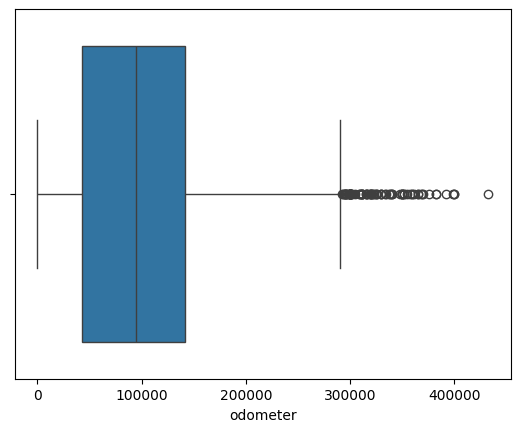

In [ ]:
sns.boxplot(data=df,x='odometer')

## UNIVARIATE CATEGORICAL ANALYSIS

In [ ]:
df.select_dtypes(include='object').columns

Index(['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')

# MANUFACTURER

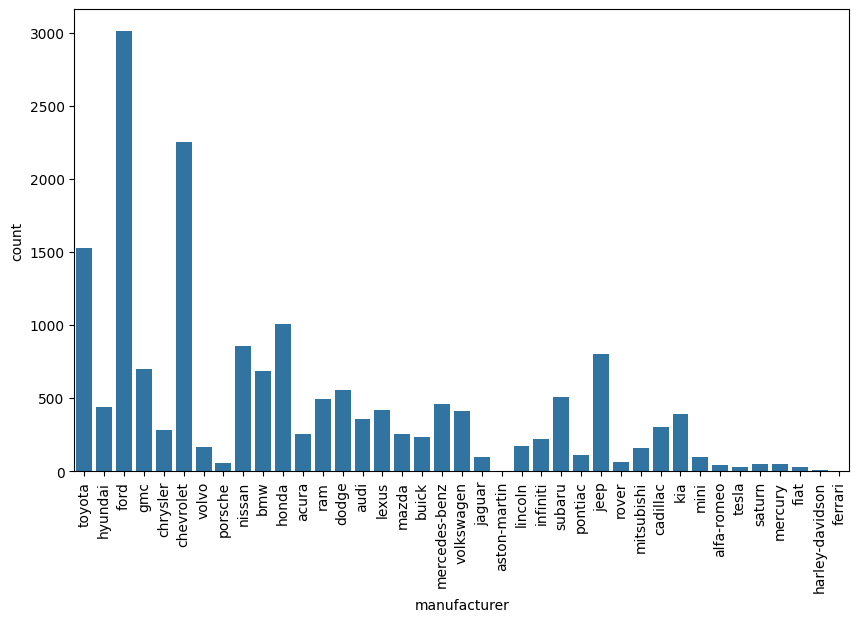

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='manufacturer')
plt.xticks(rotation=90)
plt.show()

# MODEL

In [ ]:
top_models=df.model.value_counts().head(20).index

In [ ]:
temp_df=df[df['model'].isin(top_models)]

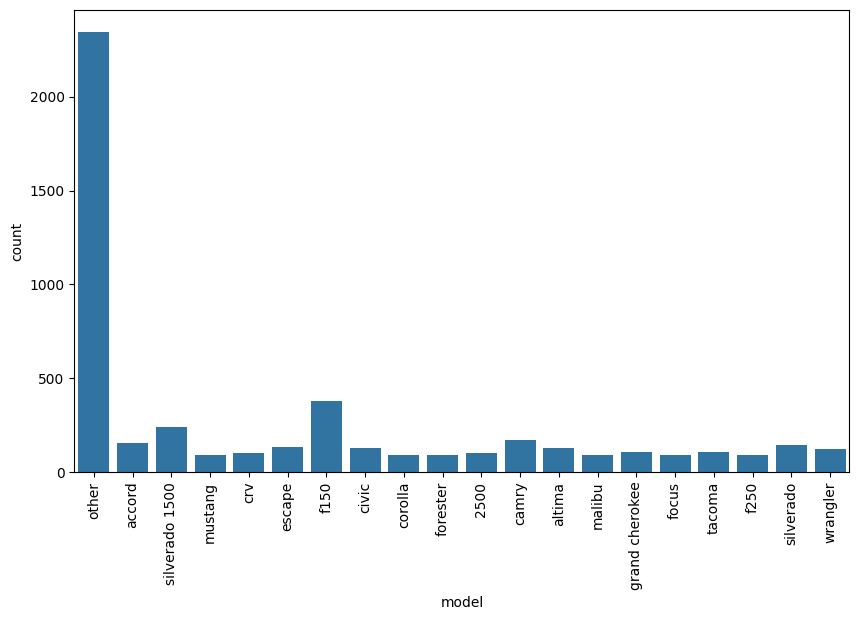

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=temp_df,x='model')
plt.xticks(rotation=90)
plt.show()

#condition

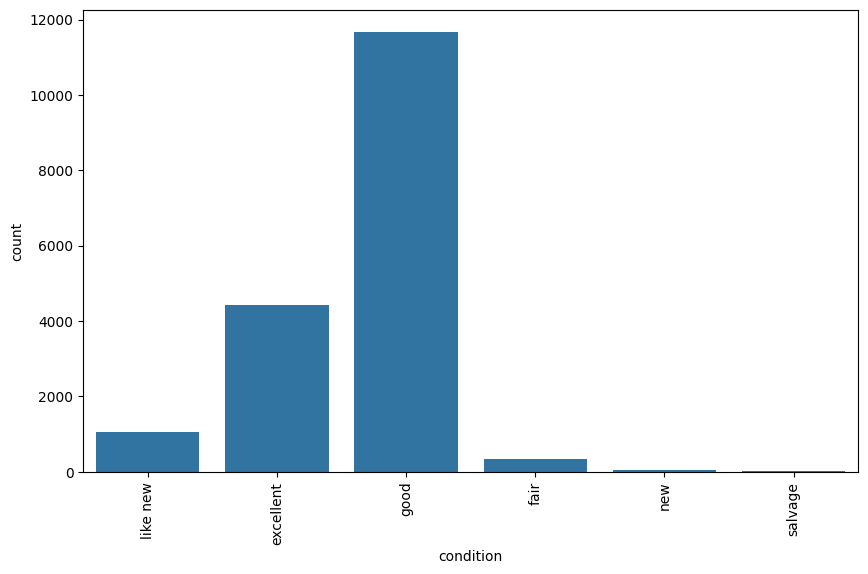

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='condition')
plt.xticks(rotation=90)
plt.show()


# cylinders

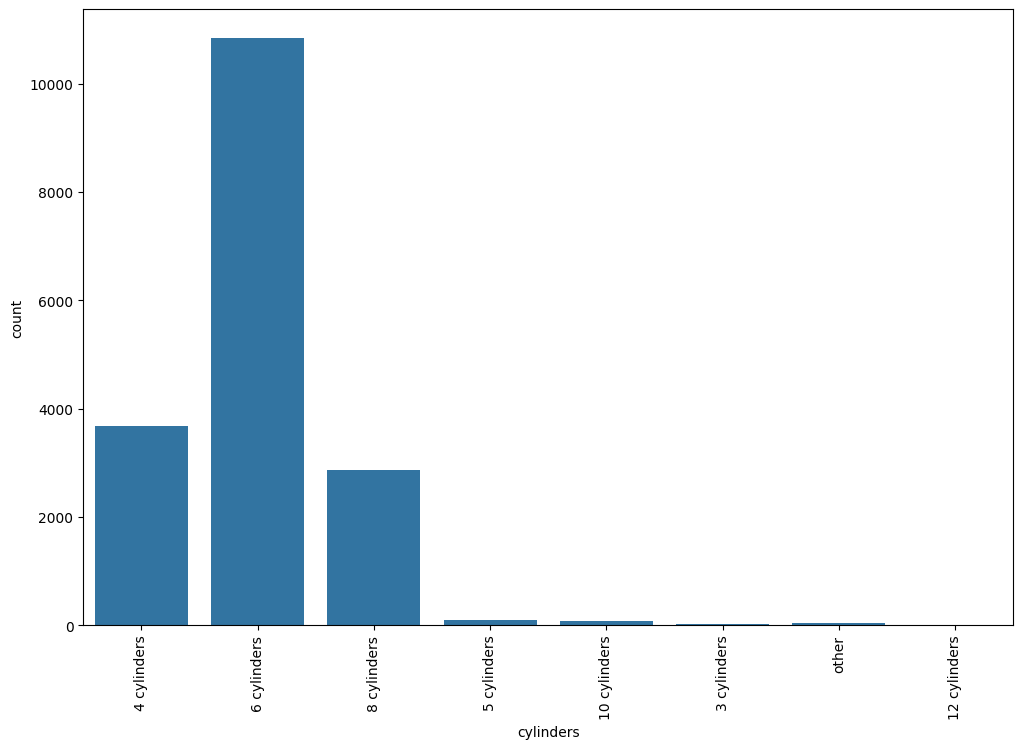

In [ ]:
plt.figure(figsize=(12,8))
sns.countplot(data=df,x='cylinders')
plt.xticks(rotation=90)
plt.show()

# fuel

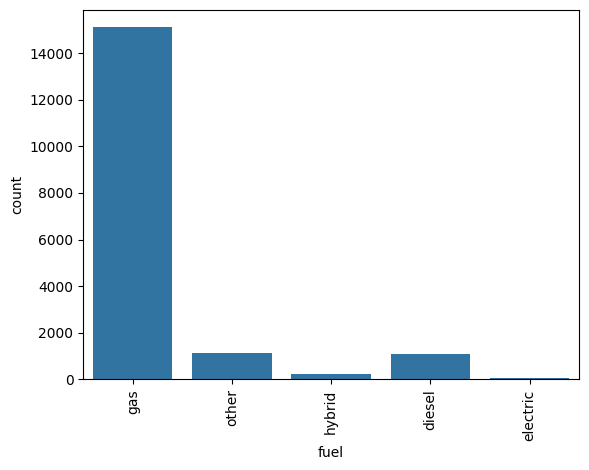

In [ ]:
sns.countplot(data=df,x='fuel')
plt.xticks(rotation=90)
plt.show()

# title_status

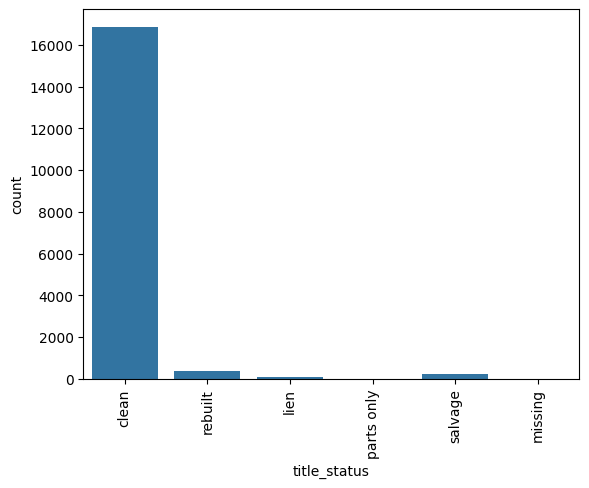

In [ ]:
sns.countplot(data=df,x='title_status')
plt.xticks(rotation=90)
plt.show()

# transmission

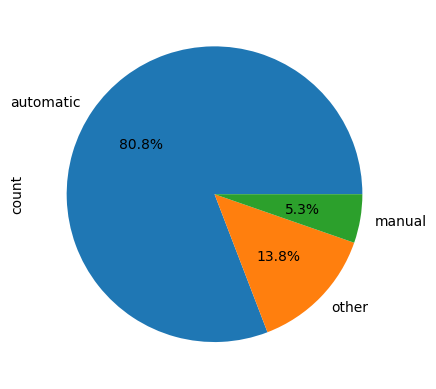

In [ ]:
df.transmission.value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.xticks(rotation=90)
plt.show()

# drive

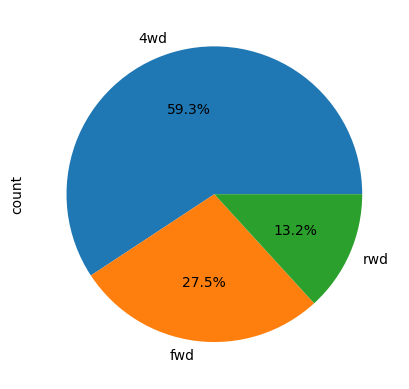

In [ ]:
df.drive.value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.xticks(rotation=90)
plt.show()

# type

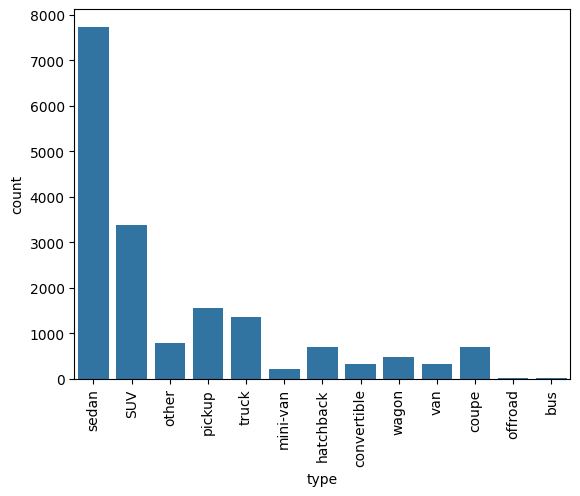

In [ ]:
sns.countplot(data=df,x='type')
plt.xticks(rotation=90)
plt.show()

# paint color

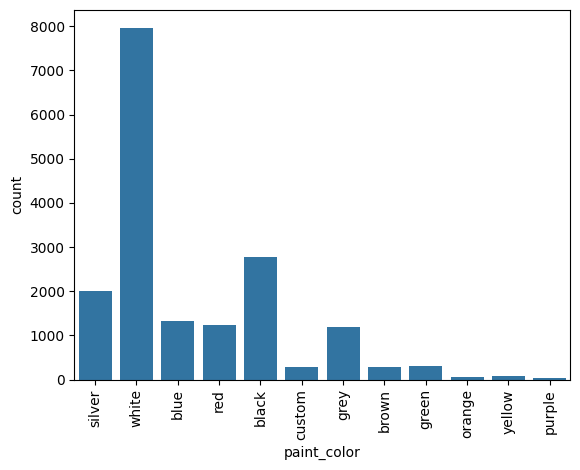

In [ ]:
sns.countplot(data=df,x='paint_color')
plt.xticks(rotation=90)
plt.show()

# state

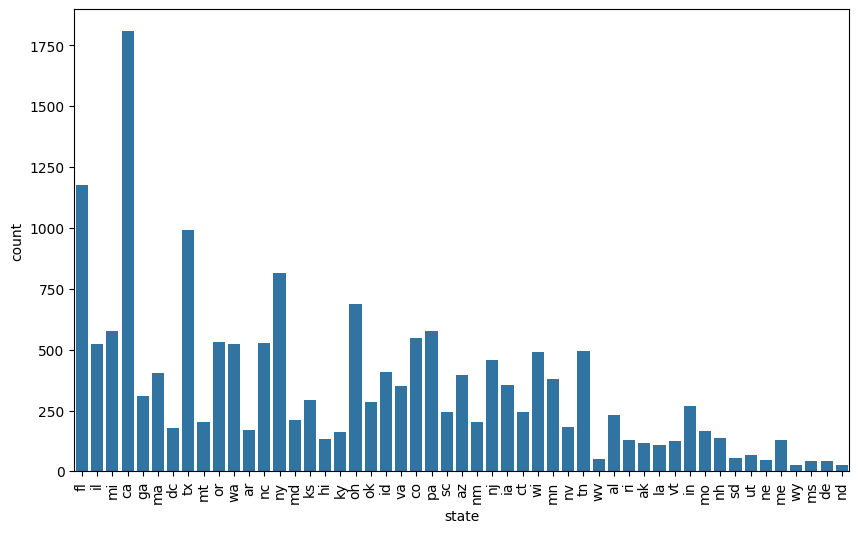

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='state')
plt.xticks(rotation=90)
plt.show()

# BIVARIATE & MULTI VARIATE ANALYSIS

In [ ]:
df.columns

Index(['year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'odometer', 'title_status', 'transmission', 'drive', 'type',
       'paint_color', 'state', 'price'],
      dtype='object')

## YEAR VS PRICE
## ODOMETER VS PRICE
## MANUFACTURER VS PRICE

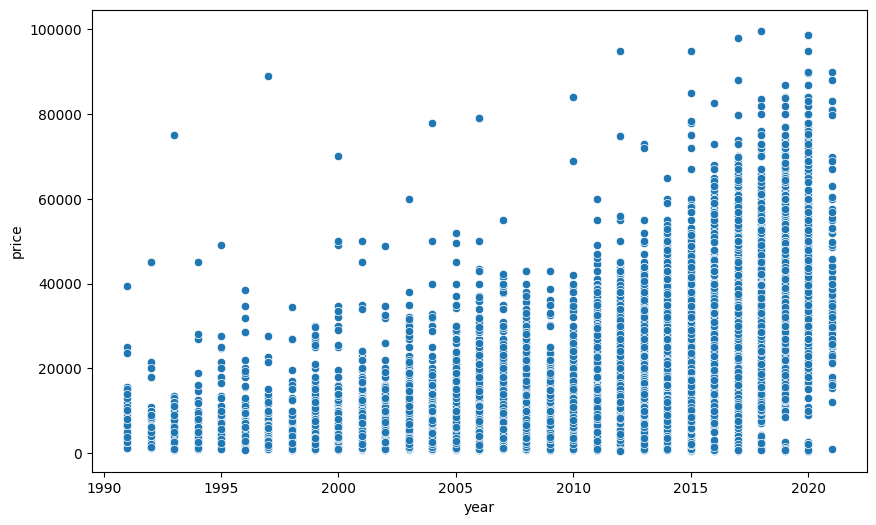

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='year',y='price')
plt.show()


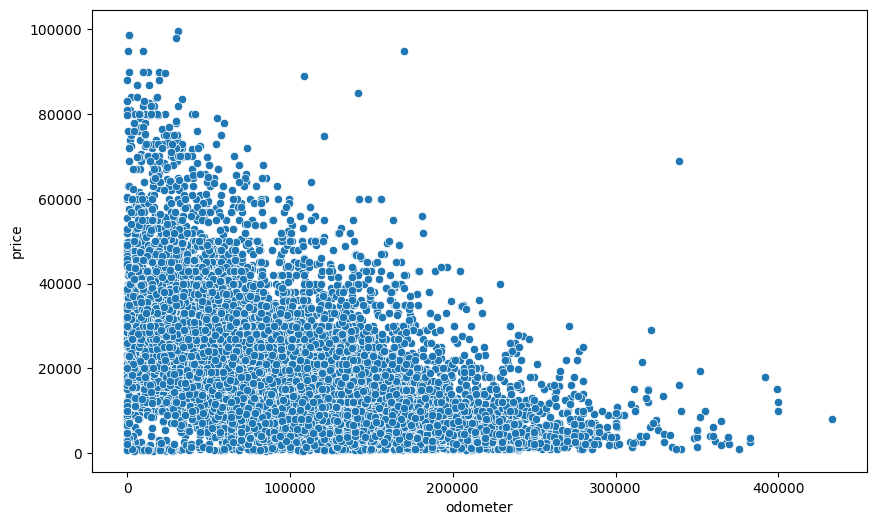

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='odometer',y='price')
plt.show()

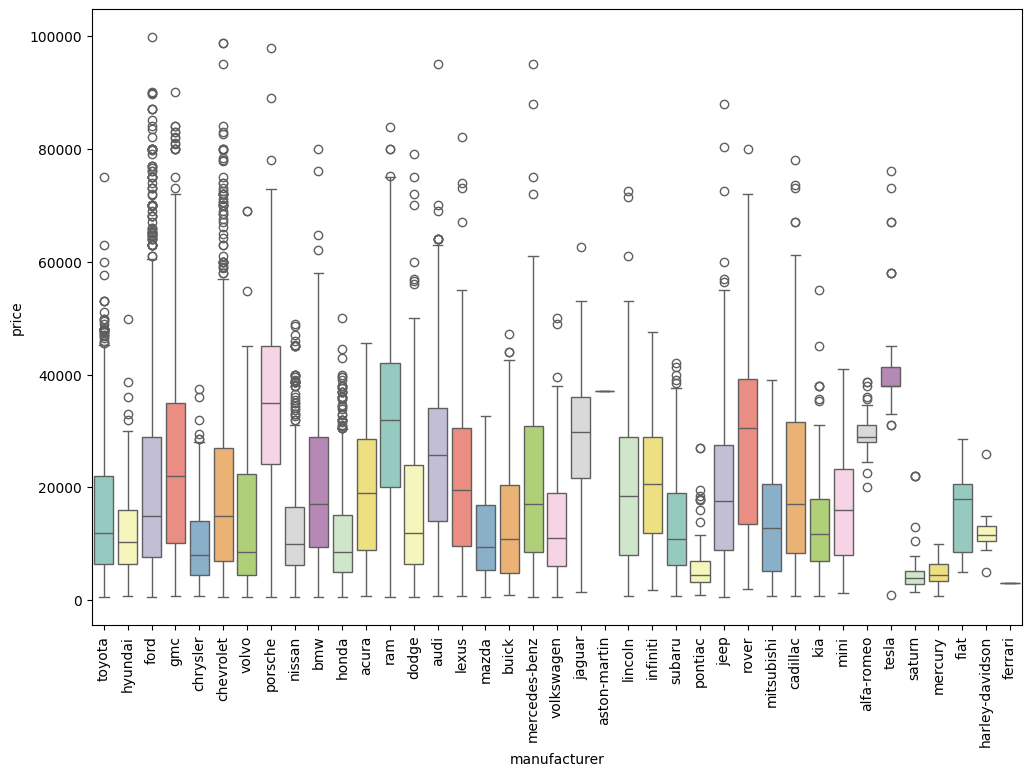

In [ ]:
plt.figure(figsize=(12,8))
sns.boxplot(y='price',x='manufacturer',data=df,hue='manufacturer',palette='Set3')
plt.xticks(rotation=90)
plt.show()

# CONDITION VS PRICE
# CYLINDERS VS PRICE

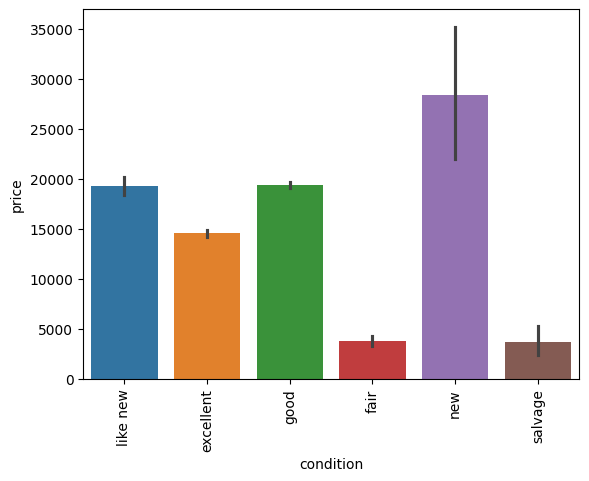

In [ ]:
sns.barplot(data=df,x='condition',y='price',hue='condition')
plt.xticks(rotation=90)
plt.show()

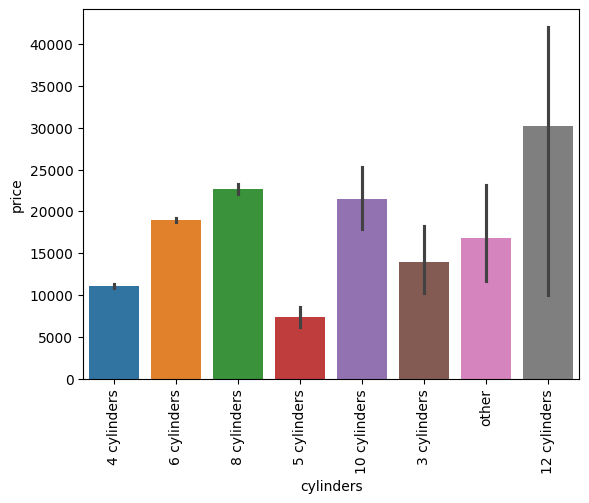

In [ ]:
sns.barplot(data=df,x='cylinders',y='price',hue='cylinders')
plt.xticks(rotation=90)
plt.show()

# TRANSMISSION VS PRICE
# DRIVE VS PRICE
# TYPE VS PRICE

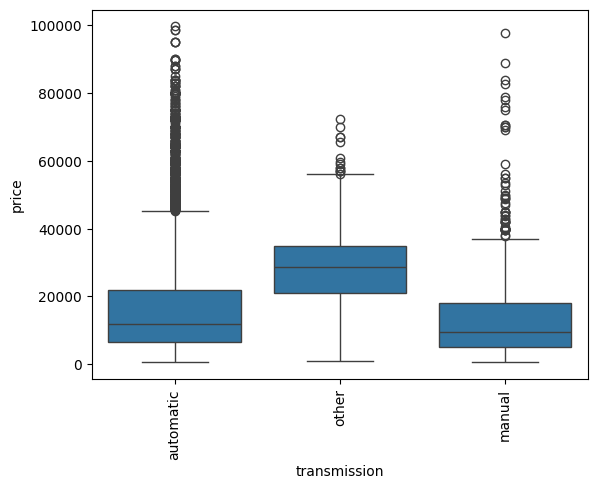

In [ ]:
sns.boxplot(data=df,x='transmission',y='price')
plt.xticks(rotation=90)
plt.show()

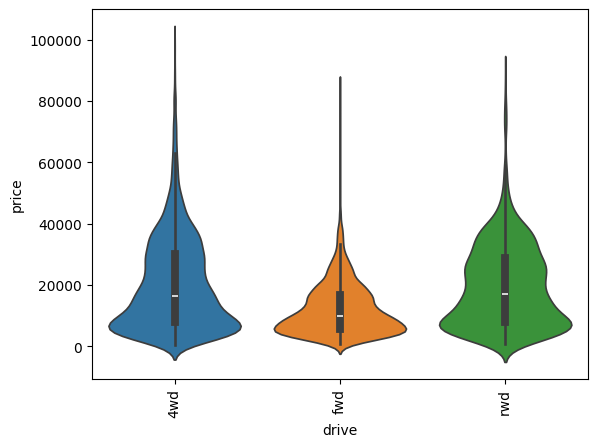

In [ ]:
sns.violinplot(data=df,x='drive',y='price',hue='drive')
plt.xticks(rotation=90)
plt.show()

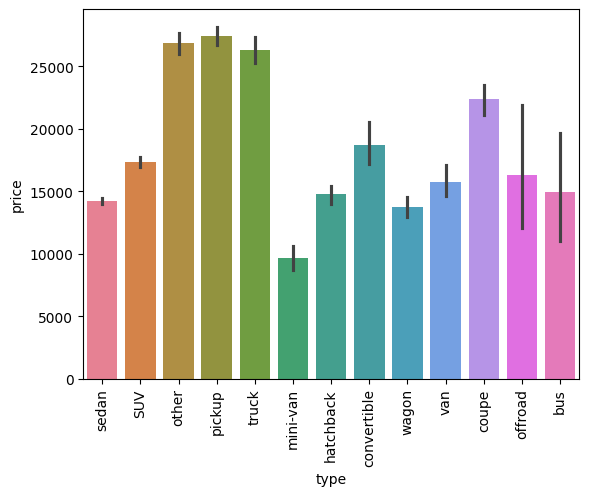

In [ ]:
sns.barplot(data=df,x='type',y='price',hue='type')
plt.xticks(rotation=90)
plt.show()

# PAINT TYPE VS PRICE
# STATE VS PRICE

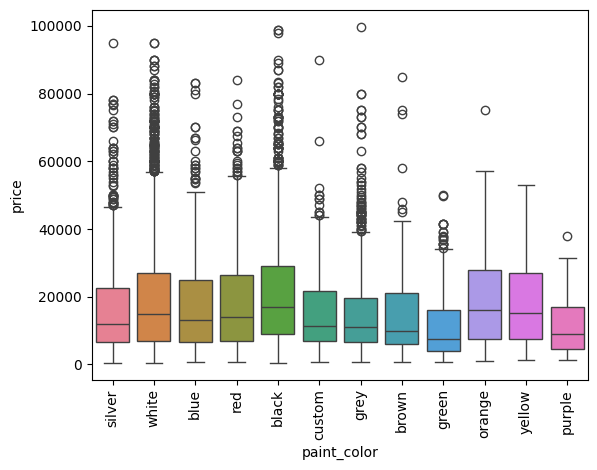

In [ ]:
sns.boxplot(data=df,x='paint_color',y='price',hue='paint_color')
plt.xticks(rotation=90)
plt.show()

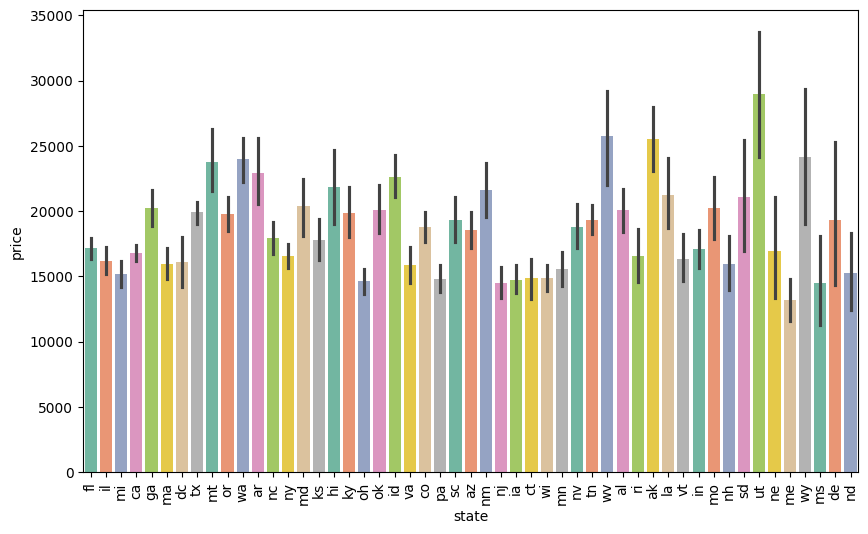

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df,x='state',y='price',hue='state',palette='Set2')
plt.xticks(rotation=90)
plt.show()

# FUEL VS PRCIE
# TITLE STATUS VS PRICE

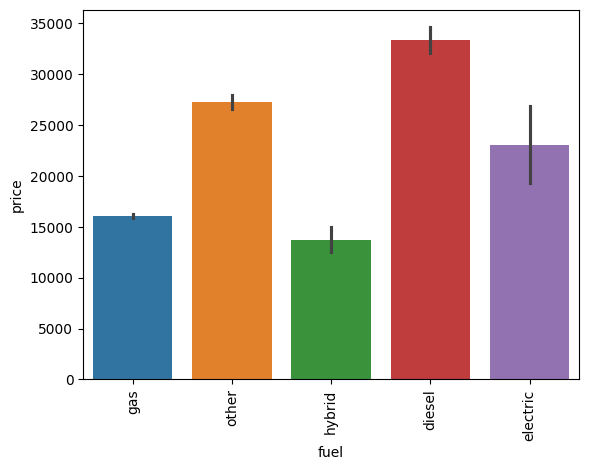

In [ ]:
sns.barplot(data=df,x='fuel',y='price',hue='fuel')
plt.xticks(rotation=90)
plt.show()

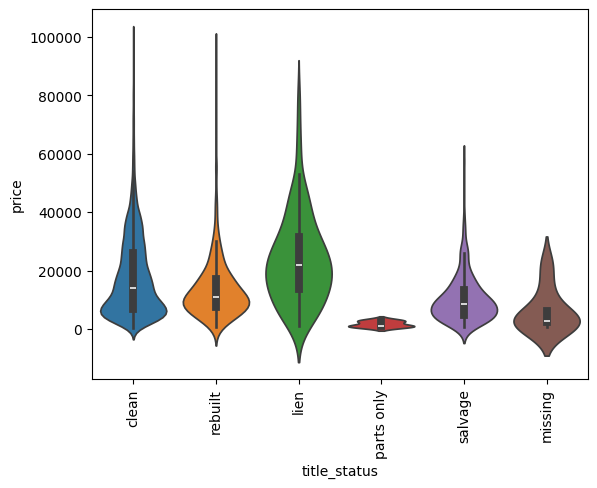

In [ ]:
sns.violinplot(data=df,x='title_status',y='price',hue='title_status')
plt.xticks(rotation=90)
plt.show()

In [ ]:
## now we will save our csv after the outliers handling and visualization on which we will perform model training

In [ ]:
df.to_csv('Finaldf.csv',index=False)